<a href="https://colab.research.google.com/github/Srishhtee/PCS221/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Part I: Randomized Sales Data Generation (NumPy)**

### 1. Initialize Random Seed

In [1]:
import numpy as np

seed = 8025320097 % (2**32)
np.random.seed(seed)

### 2. Generate Sales Data
• Create a NumPy array of random sales data for 12 months (shape = (12, 4)),
where each column represents a product category:

• Electronics, Clothing, Home & Kitchen, Sports.

• Sales valuesshould be between 1000 and 5000 units per month.

• The range should be randomized using the seed.

In [2]:
import numpy as np

# Fix the seed using modulo
seed = 8025320097 % (2**32)

np.random.seed(seed)

# Generate sales data
sales_data = np.random.randint(1000, 5001, size=(12, 4))

print(sales_data)

[[3454 4729 1117 1501]
 [4134 4144 4091 4685]
 [3376 4328 2830 3313]
 [1425 2261 1365 3576]
 [3974 2340 1684 1833]
 [2305 3239 1430 3201]
 [1856 2459 2255 3408]
 [1810 4042 2361 2250]
 [2839 3473 2092 3794]
 [4556 3754 4710 1894]
 [2306 2814 4595 2632]
 [1383 1906 2938 1239]]


### 3. Convert to DataFrame
• Convert the cleaned NumPy array into a Pandas DataFrame with:

i. Columns: Electronics, Clothing, Home & Kitchen, Sports

ii. Index: Monthsfrom Jan to Dec

In [3]:
import pandas as pd

# Define column names (product categories)
columns = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]

# Define index (months)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Convert NumPy array to DataFrame
df = pd.DataFrame(sales_data, columns=columns, index=months)

# Display DataFrame
print(df)

     Electronics  Clothing  Home & Kitchen  Sports
Jan         3454      4729            1117    1501
Feb         4134      4144            4091    4685
Mar         3376      4328            2830    3313
Apr         1425      2261            1365    3576
May         3974      2340            1684    1833
Jun         2305      3239            1430    3201
Jul         1856      2459            2255    3408
Aug         1810      4042            2361    2250
Sep         2839      3473            2092    3794
Oct         4556      3754            4710    1894
Nov         2306      2814            4595    2632
Dec         1383      1906            2938    1239


## **Part II: Data Manipulation and Analysis(Pandas)**

### 1. Display the first 5 rows and summary statistics of the DataFrame.

In [4]:
# Display first 5 rows
print("First 5 rows:\n")
print(df.head())

# Display summary statistics
print("\nSummary Statistics:\n")
print(df.describe())

First 5 rows:

     Electronics  Clothing  Home & Kitchen  Sports
Jan         3454      4729            1117    1501
Feb         4134      4144            4091    4685
Mar         3376      4328            2830    3313
Apr         1425      2261            1365    3576
May         3974      2340            1684    1833

Summary Statistics:

       Electronics    Clothing  Home & Kitchen       Sports
count    12.000000    12.00000       12.000000    12.000000
mean   2784.833333  3290.75000     2622.333333  2777.166667
std    1097.867009   928.74785     1249.837977  1050.609592
min    1383.000000  1906.00000     1117.000000  1239.000000
25%    1844.500000  2429.25000     1620.500000  1878.750000
50%    2572.500000  3356.00000     2308.000000  2916.500000
75%    3584.000000  4067.50000     3226.250000  3450.000000
max    4556.000000  4729.00000     4710.000000  4685.000000


### 2. Calculate the totalsales per category and totalsales per month.

In [5]:
# Total sales per category (column-wise sum)
category_total = df.sum(axis=0)

print("Total Sales per Category:\n")
print(category_total)


# Total sales per month (row-wise sum)
monthly_total = df.sum(axis=1)

print("\nTotal Sales per Month:\n")
print(monthly_total)

Total Sales per Category:

Electronics       33418
Clothing          39489
Home & Kitchen    31468
Sports            33326
dtype: int64

Total Sales per Month:

Jan    10801
Feb    17054
Mar    13847
Apr     8627
May     9831
Jun    10175
Jul     9978
Aug    10463
Sep    12198
Oct    14914
Nov    12347
Dec     7466
dtype: int64


### 3. Calculate the average sales growth between consecutive monthsfor each category.

In [6]:
# Calculate month-to-month percentage growth
growth = df.pct_change()

print("Monthly Growth:\n")
print(growth)


# Calculate average growth for each category
avg_growth = growth.mean()

print("\nAverage Sales Growth per Category:\n")
print(avg_growth)

Monthly Growth:

     Electronics  Clothing  Home & Kitchen    Sports
Jan          NaN       NaN             NaN       NaN
Feb     0.196873 -0.123705        2.662489  2.121252
Mar    -0.183358  0.044402       -0.308238 -0.292850
Apr    -0.577903 -0.477588       -0.517668  0.079384
May     1.788772  0.034940        0.233700 -0.487416
Jun    -0.419980  0.384188       -0.150831  0.746318
Jul    -0.194794 -0.240815        0.576923  0.064667
Aug    -0.024784  0.643758        0.047007 -0.339789
Sep     0.568508 -0.140772       -0.113935  0.686222
Oct     0.604790  0.080910        1.251434 -0.500791
Nov    -0.493854 -0.250400       -0.024416  0.389652
Dec    -0.400260 -0.322672       -0.360609 -0.529255

Average Sales Growth per Category:

Electronics       0.078546
Clothing         -0.033432
Home & Kitchen    0.299623
Sports            0.176127
dtype: float64


### 4. Add the following columns to the DataFrame:
• Total Sales: Sum of all categories per month.

• Growth Rate: Percentage change in Total Salesfrom the previous month.

In [7]:
# Add Total Sales column (row-wise sum)
df["Total Sales"] = df.sum(axis=1)

print("DataFrame with Total Sales:\n")
print(df)


# Add Growth Rate column (percentage change)
df["Growth Rate"] = df["Total Sales"].pct_change() * 100

print("\nDataFrame with Growth Rate:\n")
print(df)

DataFrame with Total Sales:

     Electronics  Clothing  Home & Kitchen  Sports  Total Sales
Jan         3454      4729            1117    1501        10801
Feb         4134      4144            4091    4685        17054
Mar         3376      4328            2830    3313        13847
Apr         1425      2261            1365    3576         8627
May         3974      2340            1684    1833         9831
Jun         2305      3239            1430    3201        10175
Jul         1856      2459            2255    3408         9978
Aug         1810      4042            2361    2250        10463
Sep         2839      3473            2092    3794        12198
Oct         4556      3754            4710    1894        14914
Nov         2306      2814            4595    2632        12347
Dec         1383      1906            2938    1239         7466

DataFrame with Growth Rate:

     Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
Jan         3454      4729      

### 5. Apply a randomized discount:
• If your roll number is even, apply a 10% discount to the Electronics category.

• If odd, apply a 15% discount to the Clothing category.

In [8]:
# Roll number
roll_no = 8025320097

# Check even or odd
if roll_no % 2 == 0:
    # Even → 10% discount on Electronics
    df["Electronics"] = df["Electronics"] * 0.90
    print("10% discount applied to Electronics")
else:
    # Odd → 15% discount on Clothing
    df["Clothing"] = df["Clothing"] * 0.85
    print("15% discount applied to Clothing")

# Display updated DataFrame
print("\nUpdated DataFrame:\n")
print(df)

15% discount applied to Clothing

Updated DataFrame:

     Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
Jan         3454   4019.65            1117    1501        10801          NaN
Feb         4134   3522.40            4091    4685        17054    57.892788
Mar         3376   3678.80            2830    3313        13847   -18.804972
Apr         1425   1921.85            1365    3576         8627   -37.697696
May         3974   1989.00            1684    1833         9831    13.956184
Jun         2305   2753.15            1430    3201        10175     3.499135
Jul         1856   2090.15            2255    3408         9978    -1.936118
Aug         1810   3435.70            2361    2250        10463     4.860694
Sep         2839   2952.05            2092    3794        12198    16.582242
Oct         4556   3190.90            4710    1894        14914    22.265945
Nov         2306   2391.90            4595    2632        12347   -17.212016
Dec         1383   162

## **Part III: Visualizations(Matplotlib and Seaborn)**

### 1. Plot monthly salestrendsfor each category using line plots.

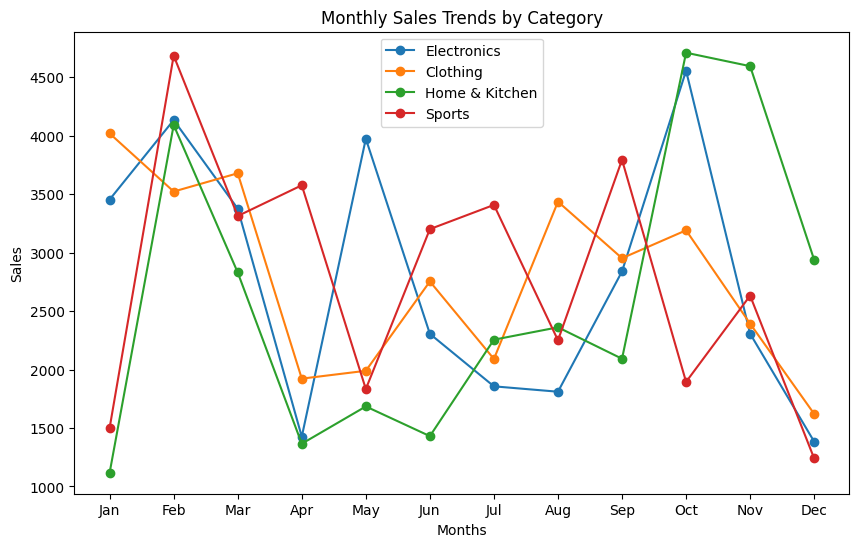

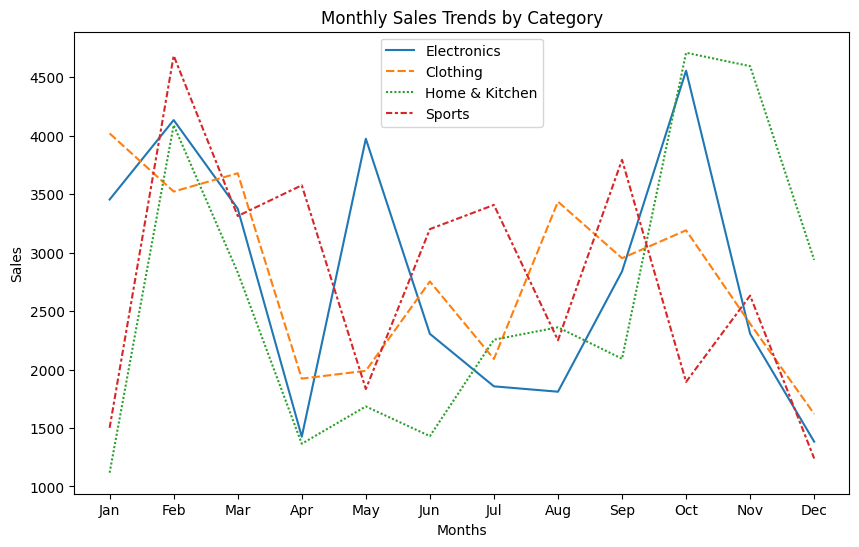

In [9]:
import matplotlib.pyplot as plt

# Plot line graph
plt.figure(figsize=(10,6))

for column in ["Electronics", "Clothing", "Home & Kitchen", "Sports"]:
    plt.plot(df.index, df[column], marker='o', label=column)

# Labels and title
plt.title("Monthly Sales Trends by Category")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.legend()

# Show plot
plt.show()



import seaborn as sns

plt.figure(figsize=(10,6))

sns.lineplot(data=df[["Electronics", "Clothing", "Home & Kitchen", "Sports"]])

plt.title("Monthly Sales Trends by Category")
plt.xlabel("Months")
plt.ylabel("Sales")

plt.show()

### 2. Create the following plots:
• Box plotsto show the sales distribution for each category.

/tmp/ipykernel_16670/1306371759.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


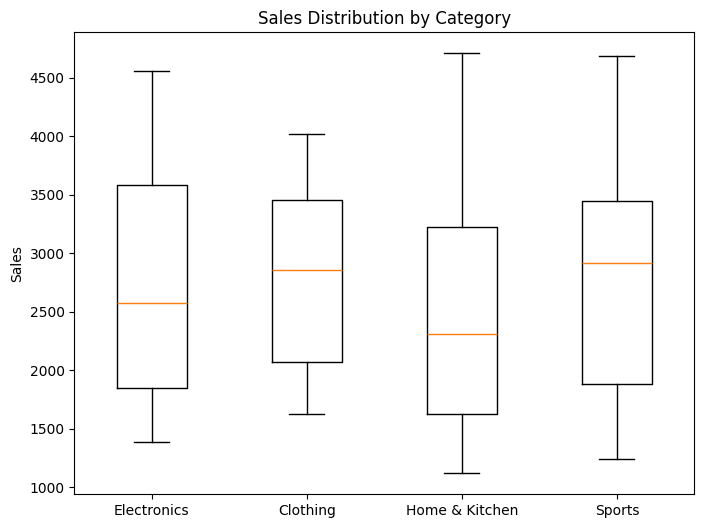

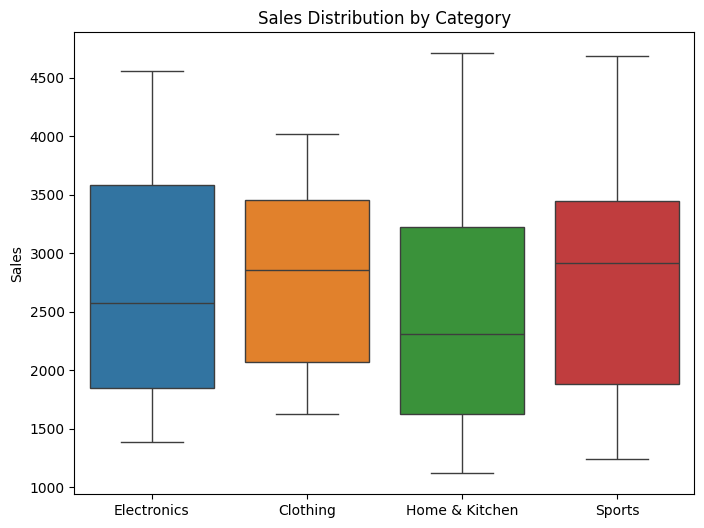

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Box plot for all categories
plt.boxplot([
    df["Electronics"],
    df["Clothing"],
    df["Home & Kitchen"],
    df["Sports"]
], labels=["Electronics", "Clothing", "Home & Kitchen", "Sports"])

plt.title("Sales Distribution by Category")
plt.ylabel("Sales")

plt.show()



import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(data=df[["Electronics", "Clothing", "Home & Kitchen", "Sports"]])

plt.title("Sales Distribution by Category")
plt.ylabel("Sales")

plt.show()

### Q.2 For the array: array = np.array([[1, -2, 3],[-4, 5, -6]])
i. Find element-wise absolute value

ii. Find the 25th, 50th, and 75th percentile of flattened array, for each column, for each row.

iii. Mean, Median and Standard Deviation of flattened array, of each column, and
each row

In [11]:
import numpy as np

# Given array
array = np.array([[1, -2, 3],
                  [-4, 5, -6]])


# (i) Find element-wise absolute value

abs_array = np.abs(array)
print("Absolute Value:\n", abs_array)



# (ii) Find the 25th, 50th, and 75th percentile
# (a) Flattened array
# (b) For each column
# (c) For each row


# Flattened array
flat = array.flatten()
print("\nPercentiles (Flattened):", np.percentile(flat, [25, 50, 75]))

# Column-wise percentiles
print("\nPercentiles (Column-wise):\n", np.percentile(array, [25, 50, 75], axis=0))

# Row-wise percentiles
print("\nPercentiles (Row-wise):\n", np.percentile(array, [25, 50, 75], axis=1))


# (iii) Mean, Median, Standard Deviation
# (a) Flattened array
# (b) For each column
# (c) For each row


# Flattened
print("\nMean (Flattened):", np.mean(flat))
print("Median (Flattened):", np.median(flat))
print("Std Dev (Flattened):", np.std(flat))

# Column-wise
print("\nMean (Column-wise):", np.mean(array, axis=0))
print("Median (Column-wise):", np.median(array, axis=0))
print("Std Dev (Column-wise):", np.std(array, axis=0))

# Row-wise
print("\nMean (Row-wise):", np.mean(array, axis=1))
print("Median (Row-wise):", np.median(array, axis=1))
print("Std Dev (Row-wise):", np.std(array, axis=1))

Absolute Value:
 [[1 2 3]
 [4 5 6]]

Percentiles (Flattened): [-3.5 -0.5  2.5]

Percentiles (Column-wise):
 [[-2.75 -0.25 -3.75]
 [-1.5   1.5  -1.5 ]
 [-0.25  3.25  0.75]]

Percentiles (Row-wise):
 [[-0.5 -5. ]
 [ 1.  -4. ]
 [ 2.   0.5]]

Mean (Flattened): -0.5
Median (Flattened): -0.5
Std Dev (Flattened): 3.8622100754188224

Mean (Column-wise): [-1.5  1.5 -1.5]
Median (Column-wise): [-1.5  1.5 -1.5]
Std Dev (Column-wise): [2.5 3.5 4.5]

Mean (Row-wise): [ 0.66666667 -1.66666667]
Median (Row-wise): [ 1. -4.]
Std Dev (Row-wise): [2.05480467 4.78423336]


### Q.3 For the array: a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0]).
i. Find floor, ceiling and truncated value,rounded values

In [12]:
import numpy as np

# Given array
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

# (i) Find floor, ceiling, truncated and rounded values

# Floor values (nearest lower integer)
print("Floor Values:\n", np.floor(a))

# Ceiling values (nearest higher integer)
print("\nCeiling Values:\n", np.ceil(a))

# Truncated values (remove decimal part)
print("\nTruncated Values:\n", np.trunc(a))

# Rounded values (nearest integer)
print("\nRounded Values:\n", np.round(a))

Floor Values:
 [-2. -2. -1.  0.  1.  1.  3.]

Ceiling Values:
 [-1. -1. -0.  1.  2.  2.  3.]

Truncated Values:
 [-1. -1. -0.  0.  1.  1.  3.]

Rounded Values:
 [-2. -2. -0.  0.  2.  2.  3.]


### Q.4 WAP to swap two elementsin a list in Python Using a Temporary Variable.

In [13]:
# Given list
lst = [10, 20, 30, 40, 50]

# Positions to swap (example: index 1 and 3 → 20 and 40)
i, j = 1, 3

print("Original List:", lst)

# Using temporary variable
temp = lst[i]
lst[i] = lst[j]
lst[j] = temp

print("List after swapping:", lst)

Original List: [10, 20, 30, 40, 50]
List after swapping: [10, 40, 30, 20, 50]


### Q.5 Write a Python program to swap two elementsin a set by converting it to a list first.

In [14]:
# Given set
s = {10, 20, 30, 40, 50}

print("Original Set:", s)

# Convert set to list
lst = list(s)

# Choose positions to swap (example: index 1 and 3)
i, j = 1, 3

# Swap using temporary variable
temp = lst[i]
lst[i] = lst[j]
lst[j] = temp

# Convert back to set
s = set(lst)

print("Set after swapping:", s)

Original Set: {50, 20, 40, 10, 30}
Set after swapping: {40, 10, 50, 20, 30}
